In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

%matplotlib inline 

In [2]:
rng = np.random.RandomState(42)
def make_emails(n, is_spam):
    if is_spam:
        return pd.DataFrame({
            'free_freq':   rng.beta(3, 8, n),
            'win_freq':    rng.beta(2, 8, n),
            'offer_freq':  rng.beta(3, 7, n),
            'exclaim_cnt': rng.poisson(4, n),
            'caps_ratio':  rng.beta(3, 6, n),
            'msg_length':  rng.normal(220, 90, n).clip(20),
            'label': 1})
    return pd.DataFrame({
        'free_freq':   rng.beta(1, 25, n),
        'win_freq':    rng.beta(1, 30, n),
        'offer_freq':  rng.beta(1, 25, n),
        'exclaim_cnt': rng.poisson(0.7, n),
        'caps_ratio':  rng.beta(1.5, 15, n),
        'msg_length':  rng.normal(380, 160, n).clip(20),
        'label': 0})

data = pd.concat([make_emails(600, True), make_emails(900, False)],
                 ignore_index=True).sample(frac=1, random_state=1).reset_index(drop=True)
print(data.shape)
data.head() 

(1500, 7)


,free_freq,win_freq,offer_freq,exclaim_cnt,caps_ratio,msg_length,label
0,0.339725,0.205811,0.141765,3,0.257425,263.876985,1
1,0.094219,0.219500,0.339108,8,0.424988,174.611203,1
2,0.003989,0.029267,0.007510,2,0.053385,263.493616,0
3,0.200149,0.058613,0.278111,2,0.204323,260.006579,1
4,0.095618,0.019451,0.000539,1,0.227418,459.566909,0


In [3]:
print(data.isnull().sum())
print()
print(data.label.value_counts())

free_freq      0
win_freq       0
offer_freq     0
exclaim_cnt    0
caps_ratio     0
msg_length     0
label          0
dtype: int64

label
0    900
1    600
Name: count, dtype: int64


In [4]:
feature_cols = ['free_freq', 'win_freq', 'offer_freq',
                'exclaim_cnt', 'caps_ratio', 'msg_length']
x = data[feature_cols]
y = data.label

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=5, stratify=y)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape) 

(1050, 6) (1050,) (450, 6) (450,)


In [7]:
pipe = make_pipeline(StandardScaler(), SVC(random_state=0))
param_grid = {
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.01, 0.1],
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(x_train, y_train)
print('Best params:', grid_search.best_params_)
print('Best CV F1 :', round(grid_search.best_score_, 4))  

Best params: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV F1 : 0.9988


Confusion Matrix:
 [[270   0]
 [  0 180]]
Accuracy: 1.0
              precision    recall  f1-score   support

    not spam       1.00      1.00      1.00       270
        spam       1.00      1.00      1.00       180

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



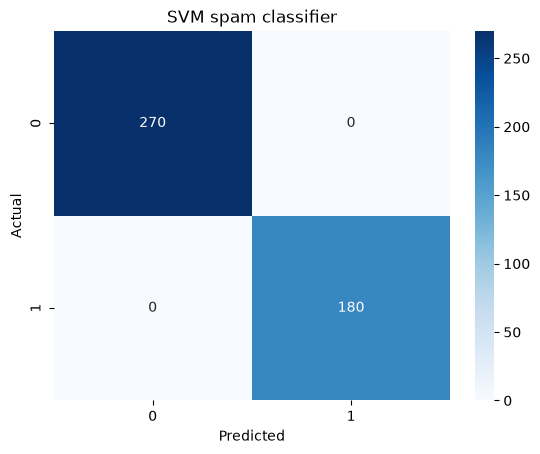

In [8]:
best = grid_search.best_estimator_
y_pred = best.predict(x_test)

print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, target_names=['not spam', 'spam']))

conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues').set(title='SVM spam classifier')
plt.show() 

In [9]:
new = pd.DataFrame([
    [0.12, 0.08, 0.10,  6,  0.35, 150],   
    [0.00, 0.00, 0.01,  0,  0.03, 420],  
], columns=feature_cols)

for label, p in zip(['Promo-style email', 'Normal email'], best.predict(new)):
    print(f"{label}: {'SPAM' if p else 'NOT SPAM'}") 

Promo-style email: SPAM
Normal email: NOT SPAM
